## Text classification on LeMonde2003 Dataset

In this notebook, we 
apply classification algorithms to newspaper articles published in 2003 in *Le Monde*. 

The data are here : https://cloud.teklia.com/index.php/s/isNwnwA7a7AWst6/download/LeMonde2003_9classes.csv.gz

Download it into the data directory : 

```
wget https://cloud.teklia.com/index.php/s/isNwnwA7a7AWst6/download/LeMonde2003_9classes.csv.gz
```

Or you can download the file directly from the URL in pandas with `pd.read_csv(url)`.`

These articles concern different subjects but we will consider only articles related to the following subjects : entreprises (ENT), international (INT), arts (ART), société (SOC), France (FRA), sports (SPO), livres (LIV), télévision (TEL) and the font page articles (UNE).


> * Load the CSV file `LeMonde2003_9classes.csv.gz` containing the articles using pandas [pd.read_csv](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html). How many articles do you have ? 
> * Plot the frequency histogram of the categories using seaborn [countplot](https://seaborn.pydata.org/tutorial/categorical.html) : `sns.countplot(data=df,y='category')`
> * Display the text of some of the article with the corresponding class using pandas [sample](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.sample.html)
> * Using the [WordCloud library](https://amueller.github.io/word_cloud/index.html), display a word cloud for the most frequent classes. You can remove the stop words using the `stopwords` option, using the list of stop words in French in `data/stop_word_fr.txt` or from the URL https://cloud.teklia.com/index.php/s/3mwZfSre4PmJcdb/download/stop_word_fr.txt



In [1]:
import pandas as pd

# load dataframe from CSV file
# YOUR CODE HERE
articles_df = pd.read_csv('LeMonde2003_9classes.csv.gz')


Nombre d'articles dans la base de données: 30165
Nombre de catégories: 7
Nombre de mots par article (moyenne): 390.4144869882314


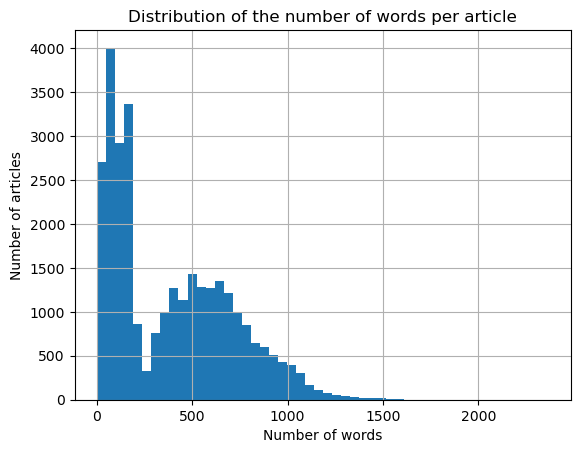

Nombre d'articles par catégorie:


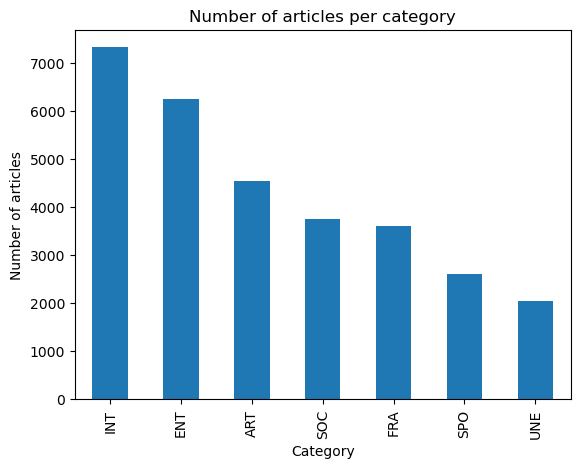

category
INT    7328
ENT    6251
ART    4552
SOC    3755
FRA    3616
SPO    2608
UNE    2055
Name: count, dtype: int64
Nombre d'articles par catégorie (détails):


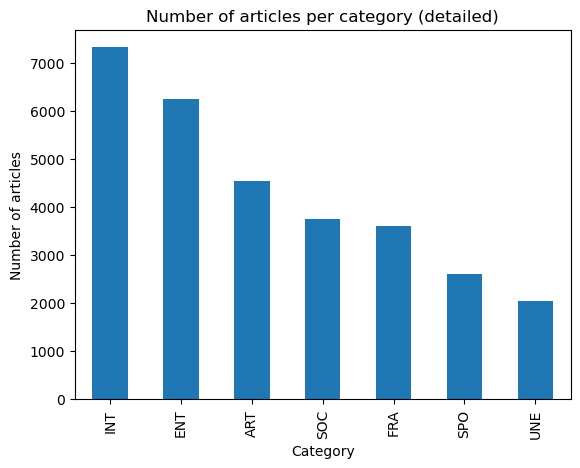

In [2]:
import seaborn as sns
%matplotlib inline
print("Nombre d'articles dans la base de données:",articles_df.shape[0])
print("Nombre de catégories:",articles_df['category'].nunique())
print("Nombre de mots par article (moyenne):",articles_df['text'].str.split().str.len().mean())
# Plot the distribution of the number of words per article
# YOUR CODE HERE
articles_df['text'].str.split().str.len().hist(bins=50)
import matplotlib.pyplot as plt
plt.title('Distribution of the number of words per article')
plt.xlabel('Number of words')
plt.ylabel('Number of articles')
plt.show()
print("Nombre d'articles par catégorie:")
# Plot the number of articles per category
articles_df['category'].value_counts().plot(kind='bar')
plt.title('Number of articles per category')
plt.xlabel('Category')
plt.ylabel('Number of articles')
plt.show()
print(articles_df['category'].value_counts())
print("Nombre d'articles par catégorie (détails):")
articles_df['category'].value_counts().to_frame().reset_index().rename(columns={'index': 'category', 'category': 'count'})
# Plot the number of articles per category (detailed)
articles_df['category'].value_counts().plot(kind='bar')
plt.title('Number of articles per category (detailed)')
plt.xlabel('Category')
plt.ylabel('Number of articles')
plt.show()
# Plot the statistics of category
# YOUR CODE HERE

In [3]:
# Print examples of the articles
pd.set_option('display.max_colwidth', None)
# YOUR CODE HERE
pd.set_option('display.max_colwidth', None)

sampling = articles_df.sample(2)
sampling

,text,category
29731,couple mythique du cinéma populaire français le vieux flic magouilleur et son stagiaire trop prompt à appliquer la loi reviennent pour de nouvelles aventures tandis que l'inspecteur légaliste thierry lhermitte fait de son mieux pour oublier ses écarts d'antan le retraité boirond philippe noiret se sert du tiercé pour berner les commerçants du quartier traqué par la communauté chinoise qui le soupçonne d'avoir dérobé le magot qu'elle lui avait confié filé par la police qui se méfie de ses airs faussement candides boirond endosse l'identité d'un mort en croyant pouvoir être peinard mais il s'aperçoit qu'il s'est glissé dans la peau d'un ancien truand rattrapé par ses vieilles relations le troisième épisode de cette saga a perdu beaucoup de la verve du premier en même temps que sa veine sociologique l'un des problèmes de ripoux 3 tient à la faiblesse des seconds rôles au rang desquels figure la glaciale laurence boccolini une satisfaction toutefois dans le rôle du gamin néophyte voulant devenir flic et multipliant les gaffes lorant deutsch est parfait,ART
3216,des bérets verts américains qui relèvent du commandement des forces spéciales ont opéré secrètement en irak huit mois avant même l'annonce par george bush de sa décision d'entrer en guerre contre saddam hussein cette information révélée lundi 28 avril par le commandement central américain centcom est rapportée par l'agence associated press sous la responsabilité d'un officier identifié sous le sobriquet de capitaine mike une équipe du 5e groupe des forces spéciales un corps de bérets verts normalement cantonné à fort bragg caroline du nord se trouvait depuis août-septembre 2002 dans un des faubourgs de l'ouest de bagdad avant le déclenchement de la guerre ces commandos sont parvenus à établir des relations confiantes avec la population après s'être fait bien accueillir par les plus âgés ils ont ravitaillé la population et tout récemment ils l'ont aidée une fois bagdad tombée à élire un conseil des anciens censé la représenter auprès de l'administration provisoire le centcom précise que le choix de ces représentants s'est fait hors de la pression du commando américain nous avons été envoyés là pour gagner le coeur et l'esprit de la population fait dire le centcom au capitaine mike qui n'a pas été présenté à la presse nous étions sincères et ils nous l'ont bien rendu au fur et à mesure que le temps a passé ils ont réalisé que nous étions là pour les aider et les secourir près de l'aéroport le choix de ce faubourg de bagdad pour y laisser une équipe des forces spéciales est significatif ce quartier est en effet tout proche de l'aéroport de la capitale baptisé à l'origine saddam hussein international airport cet aérodrome civil a été le premier objectif des marines américains dès le 4 avril avant qu'ils ne commencent à entrer dans la ville les deux jours suivants le 13 avril un bataillon d'un régiment d'artillerie américain en prenait le contrôle ainsi que celui du secteur avoisinant cette implantation a été largement facilitée par la présence des bérets verts antérieure au déploiement de ce bataillon il est exceptionnel qu'un haut commandement militaire se livre comme c'est aujourd'hui le cas à des commentaires même partiels sur le travail secret de ses forces spéciales dès la mi-février cependant la presse américaine avait laissé entendre que des commandos opéraient en irak depuis plus d'un mois en réalité il apparaît que le 5e groupe était à l'oeuvre depuis plus longtemps et en tout cas bien avant la décision de m. bush de lancer la campagne liberté pour l'irak à partir du 20 mars selon certaines informations les etats-unis auraient intégré au total quelque 10 000 hommes de leurs forces spéciales dans le dispositif du général tommy franks les méthodes des bérets verts sont souvent les mêmes des petites équipes d'une douzaine d'hommes mènent des missions de reconnaissance derrière les lignes adverses aident à mettre en place des guérillas conduisent des a

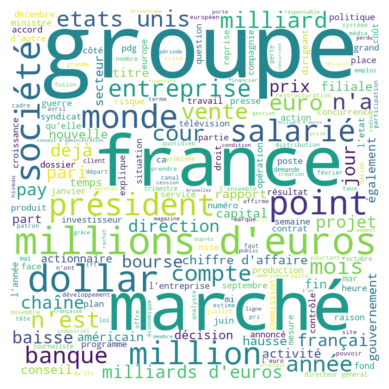

<Figure size 640x480 with 0 Axes>

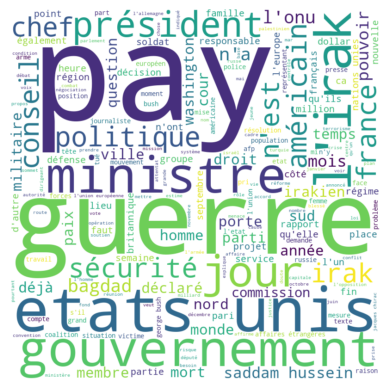

<Figure size 640x480 with 0 Axes>

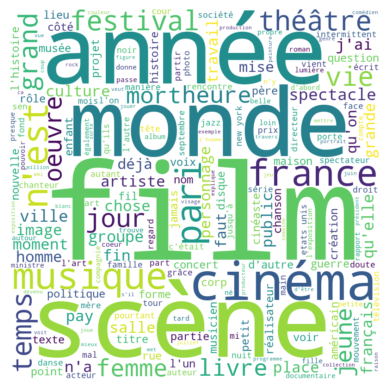

<Figure size 640x480 with 0 Axes>

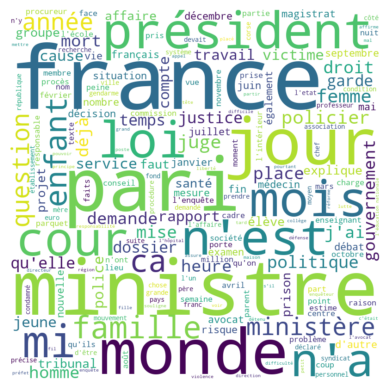

<Figure size 640x480 with 0 Axes>

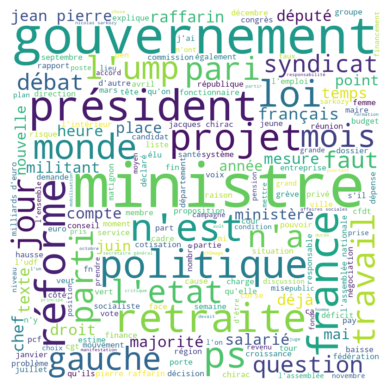

<Figure size 640x480 with 0 Axes>

In [4]:
from wordcloud import WordCloud
# Display one wordcloud for each of the most frequent classes

from wordcloud import WordCloud
STOPWORDS = [x.strip() for x in open('data/stop_word_fr.txt').readlines()]
import matplotlib.pyplot as plt

# plot a word cloud for each category
for cat in ['ENT', 'INT',  'ART', 'SOC', 'FRA']:
    text =articles_df[articles_df.category==cat].text.str.cat(sep=' ')
    
    wc = WordCloud(width = 800, height =800, background_color="white",
               stopwords=STOPWORDS, min_font_size=10)
   
    # generate word cloud
    cloud = wc.generate(text)
    plt.imshow(cloud, interpolation='bilinear')
    plt.axis("off")
    plt.figure()
    plt.show()


## Bag-of-word representation

In order to apply machine learning algorithms to text, documents must be transformed into vectors. The most simple and standard way to transform a document into a vector is the *bag-of-word* encoding.

The idea is very simple : 

1. define the set of all the possible words that can appear in a document; denote its size by `max_features`.
2. for each document,  encode it with a vector of size `max_features`, with the value of the ith component of the vector equal to the number of time the ith word appears in the document.

See [the wikipedia article on Bag-of-word](https://en.wikipedia.org/wiki/Bag-of-words_model) for an example.

Scikit-learn proposes different methods to encode text into vectors : [CountVectorizer](http://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) and [TfidfTransformer](http://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfTransformer.html).

The encoder must first be trained on the train set and applied to the different sets, for example with the 200  words : 

	from sklearn.feature_extraction.text import CountVectorizer
	vectorizer = CountVectorizer(max_features=200)
    vectorizer.fit(X_train)
    X_train_counts = vectorizer.transform(X_train)
    X_test_counts = vectorizer.transform(X_test)
        
**Question**:

> * Split the dataset LeMonde2003 into train set (80%), dev set (10%)  and test set (10%) using scikit-learn [train_test_split](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)
> * For each set, transform the text of the articles into vectors using the `CountVectorizer`, considering the 1000 most frequent words. 
> * Train a naive bayes classifier on the data. 
> * Evaluate the classification accuracy on the train, dev and test sets using the [score](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html#sklearn.naive_bayes.MultinomialNB.score) method. 

> ***Important*** : the test set must not be used during the training phase, and learning the vector representation of the words is part of the training. The dev set should be an evaluation of the test set.



In [5]:

# YOUR CODE HERE
from sklearn.model_selection import train_test_split
# YOUR CODE HERE
train_set, inter_set = train_test_split(articles_df, test_size=0.2, train_size=0.8)
dev_set, test_set = train_test_split(inter_set, test_size=0.5, train_size=0.5)

X_train = train_set.text.tolist()
y_train = train_set.category.tolist()
print(len(X_train))
print(len(y_train))

X_dev = dev_set.text.tolist()
y_dev = dev_set.category.tolist()
print(len(X_dev))
print(len(y_dev))

X_test = test_set.text.tolist()
y_test = test_set.category.tolist()
print(len(X_test))
print(len(y_test))

24132
24132
3016
3016
3017
3017


In [6]:
from sklearn.feature_extraction.text import CountVectorizer
# Create document vectors
# YOUR CODE HERE
# create the vectorizer object
vectorizer=CountVectorizer(analyzer='word', stop_words=STOPWORDS, max_features=1000)
# fit on train data
vectorizer.fit(X_train)
# apply it on train and dev data
X_train_counts=vectorizer.transform(X_train)
X_dev_counts=vectorizer.transform(X_dev)
X_test_counts=vectorizer.transform(X_test)
# check the shape of the vectors
print(X_train_counts.shape)
print(X_dev_counts.shape)
print(X_test_counts.shape)

/users/eleves-a/2024/zakarya.elmimouni/.local/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:408: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['quelqu'] not in stop_words.
  warnings.warn(


(24132, 1000)
(3016, 1000)
(3017, 1000)


In [7]:
from sklearn.naive_bayes import MultinomialNB
# train a Naive Bayes classifier
# YOUR CODE HERE
# create the MultinomialNB

clf = MultinomialNB()
# Train 
clf.fit(X_train_counts, y_train)
# Evaluate 
print("Train accuracy: ", clf.score(X_train_counts, y_train))
print("Dev accuracy: ", clf.score(X_dev_counts, y_dev))
print("Test accuracy: ", clf.score(X_test_counts, y_test))


Train accuracy:  0.7454417371125477
Dev accuracy:  0.7281167108753316
Test accuracy:  0.7358302949950282


## TF-IDF representation

The `CountVectorizer` encodes the text using the raw frequencies of the words. However, words that are very frequent and appear in all the documents will have a strong weight whereas they are not discriminative. The *Term-Frequency Inverse-Document-Frequency* weighting scheme take into accound the number of documents in which a given word occurs. A word that appear in many document will have less weight. See [the wikipedia page](https://en.wikipedia.org/wiki/Tf%E2%80%93idf) for more details.

With scikit-learn, the `TfidfTransformer` is applied after the `CountVectorizer` :

	from sklearn.feature_extraction.text import TfidfTransformer
	tf_transformer = TfidfTransformer().fit(X_train_counts)
 	X_train_tf = tf_transformer.transform(X_train_counts)
	X_test_tf = tf_transformer.transform(X_test_counts)
	
**Question**:

> * Use the TF-IDF representation to train a Multinomial Naive Bayes classifier. Report your best test error rate and the error rates for all the configurations tested.

In [8]:
from sklearn.feature_extraction.text import TfidfTransformer
# YOUR CODE HERE
tf_transformer = TfidfTransformer().fit(X_train_counts)
X_train_tf = tf_transformer.transform(X_train_counts)
X_test_tf = tf_transformer.transform(X_test_counts)
X_dev_tf = tf_transformer.transform(X_dev_counts)

Train accuracy:  0.7688546328526438
Dev accuracy:  0.7503315649867374
Test accuracy:  0.762346702021876
              precision    recall  f1-score   support

         ART       0.78      0.89      0.83       453
         ENT       0.79      0.86      0.82       653
         FRA       0.64      0.70      0.67       369
         INT       0.81      0.87      0.84       722
         SOC       0.67      0.68      0.68       380
         SPO       0.88      0.75      0.81       244
         UNE       0.25      0.01      0.01       196

    accuracy                           0.76      3017
   macro avg       0.69      0.68      0.67      3017
weighted avg       0.73      0.76      0.74      3017



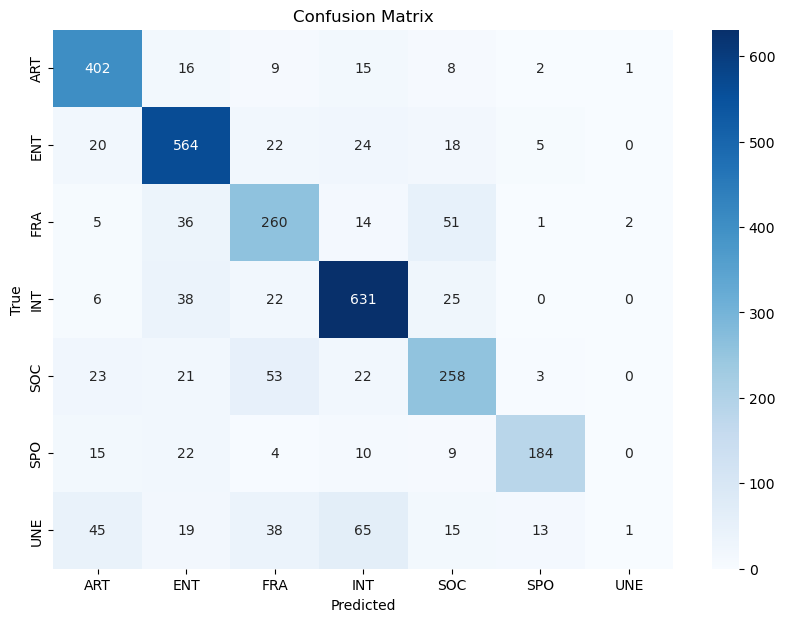

In [9]:
clf = MultinomialNB()
# Train
clf.fit(X_train_tf, y_train)
# Evaluate
print("Train accuracy: ", clf.score(X_train_tf, y_train))
print("Dev accuracy: ", clf.score(X_dev_tf, y_dev))
print("Test accuracy: ", clf.score(X_test_tf, y_test))
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# YOUR CODE HERE
# Predict the labels for the test set
y_pred = clf.predict(X_test_tf)
# Print the classification report
print(classification_report(y_test, y_pred))
# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Plot the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


Le score est plus élevé avec tf_idf qui diminue le poids des mots qui apparaîssent dans beaucoup de documents.
Cependant, on remarque que le score reste du même ordre de grandeur pour les trois ensembles de données, 


## Error analysis

The classification error rate give an evaluation of the performance for all the classes. But since the classes are not equally distributed, they may not be equally well modelized. In order to get a better idea of the performance of the classifier, detailed metrics must be used : 

* [metrics.classification_report](http://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) provides a detailed analysis per class : the precision (amongst all the example classified as class X, how many are really from the classX) and the recall (amongst all the example that are from the class X, how many are classified as class X) and the F-Score which is as a weighted harmonic mean of the precision and recall.
* [metrics.confusion_matrix](http://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html) which give the confusions between the classes. It can be displayed in color with [plot_confusion_matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.plot_confusion_matrix.html#sklearn.metrics.plot_confusion_matrix).

**Question**:

> * Report the `classification_report` for your  classifier. Which classes have the best scores ? Why ?
> * Report the `confusion_matrix` for your  classifier. Which classes are the most confused ? Why ?


In [10]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# YOUR CODE HERE

y_pred = clf.predict(X_test_tf)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         ART       0.78      0.89      0.83       453
         ENT       0.79      0.86      0.82       653
         FRA       0.64      0.70      0.67       369
         INT       0.81      0.87      0.84       722
         SOC       0.67      0.68      0.68       380
         SPO       0.88      0.75      0.81       244
         UNE       0.25      0.01      0.01       196

    accuracy                           0.76      3017
   macro avg       0.69      0.68      0.67      3017
weighted avg       0.73      0.76      0.74      3017



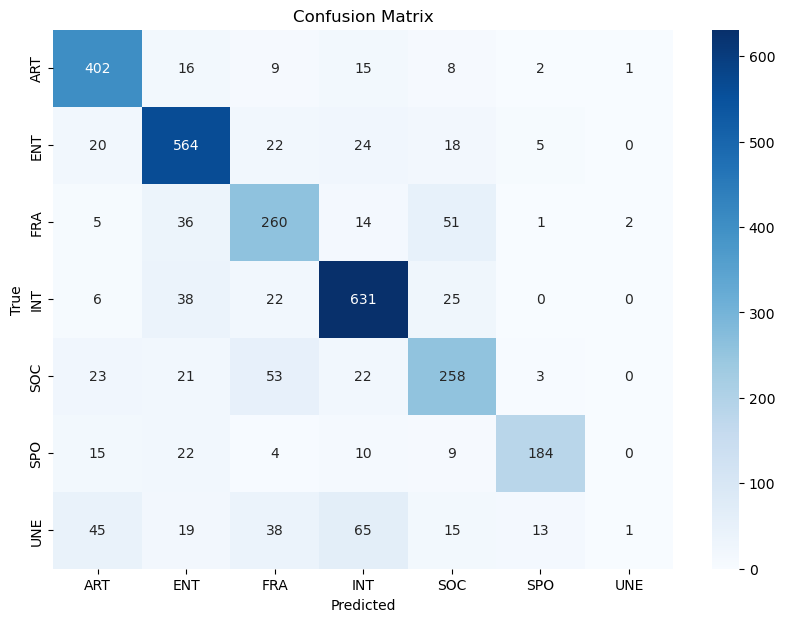

In [11]:
cm = confusion_matrix(y_test, y_pred)
# Plot the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

the most confused classes are : UNE, INT, FRA et ENT

## Data re-configuration
After the error analysis, we came to the conclusion that one of the class can not be distinguised from the others. There is no use trying to solve an impossible problem.

**Questions**:

> * Remove the class `UNE` from the original dataset and merge the semantically close classes 'FRANCE' and 'SOCIETE'
> * Plot the class statitics with seaborn
> * Create new splits
> * Retrain a NaiveBayes classifier using [TfidfVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) with the 1000 most frequent words.

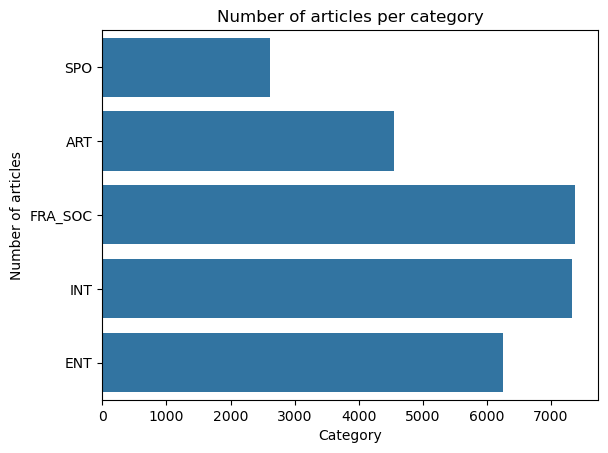

22488
22488
2811
2811
2811
2811


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
# YOUR CODE HERE

# Filter out the UNE class
# Filter out the UNE class
articles_df = articles_df[articles_df['category'] != 'UNE']
articles_df['category'] = articles_df['category'].replace({'FRA': 'FRA_SOC', 'SOC': 'FRA_SOC'})
# Plot the statistics of classes
sns.countplot(data=articles_df,y='category')
plt.title('Number of articles per category')
plt.xlabel('Category')
plt.ylabel('Number of articles')
plt.show()

# Make the splits and print the sizes for checking
train_set, inter_set = train_test_split(articles_df, test_size=0.2, train_size=0.8)
dev_set, test_set = train_test_split(inter_set, test_size=0.5, train_size=0.5)

X_train = train_set.text.tolist()
y_train = train_set.category.tolist()
print(len(X_train))
print(len(y_train))

X_dev = dev_set.text.tolist()
y_dev = dev_set.category.tolist()
print(len(X_dev))
print(len(y_dev))

X_test = test_set.text.tolist()
y_test = test_set.category.tolist()
print(len(X_test))
print(len(y_test))

In [15]:
# create the vectorizer object
vectorizer = CountVectorizer(max_features=1000)
# fit on train data
vectorizer.fit(X_train)
# apply it on train and dev data
X_train_counts = vectorizer.transform(X_train)
X_test_counts = vectorizer.transform(X_test)
X_dev_counts = vectorizer.transform(X_dev)

# Apply TfidfVectorizer
tf_transformer = TfidfTransformer().fit(X_train_counts)
X_train_tf = tf_transformer.transform(X_train_counts)
X_test_tf = tf_transformer.transform(X_test_counts)
X_dev_tf = tf_transformer.transform(X_dev_counts)

Train accuracy:  0.8384916399857701
Dev accuracy:  0.8260405549626467
Test accuracy:  0.8324439701173959
              precision    recall  f1-score   support

         ART       0.83      0.86      0.84       455
         ENT       0.84      0.82      0.83       624
     FRA_SOC       0.77      0.86      0.81       738
         INT       0.87      0.85      0.86       739
         SPO       0.98      0.67      0.80       255

    accuracy                           0.83      2811
   macro avg       0.86      0.81      0.83      2811
weighted avg       0.84      0.83      0.83      2811



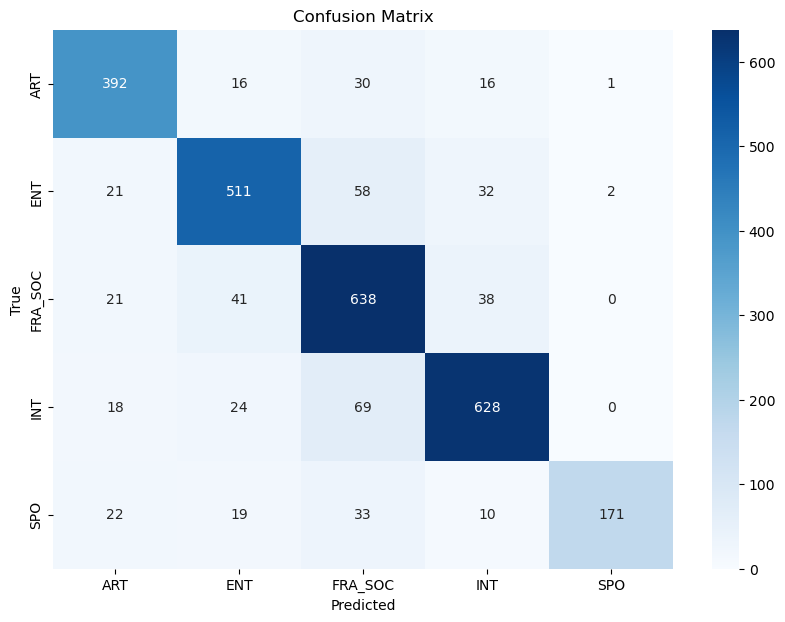

In [16]:
# create the MultinomialNB
clf = MultinomialNB()
# Train 
clf.fit(X_train_tf, y_train)
# Evaluate
print("Train accuracy: ", clf.score(X_train_tf, y_train))
print("Dev accuracy: ", clf.score(X_dev_tf, y_dev))
print("Test accuracy: ", clf.score(X_test_tf, y_test))

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# Predict the labels for the test set
y_pred = clf.predict(X_test_tf)
# Print the classification report
print(classification_report(y_test, y_pred))
# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Plot the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

Results are better than in the last time 

## What about the LLMs?

**You must write the answer to this question in a notebook hosted in your github account and give access to your supervisor.**

LLMs are reputed to have revolutionised automatic language processing. Since the introduction of BERT-type models, all language processing applications have been based on LLMs, of varying degrees of sophistication and size. These models are trained on multiple tasks and are therefore capable of performing new tasks without learning, simply from a prompt. This is known as "zero-shot learning" because there is no learning phase as such. We are going to test these models on our classification task.

Huggingface is a Franco-American company that develops tools for building applications based on Deep Learning. In particular, it hosts the huggingface.co portal, which contains numerous Deep Learning models. These models can be used very easily thanks to the [Transformer] library (https://huggingface.co/docs/transformers/quicktour) developed by HuggingFace.

Using a transform model in zero-shot learning with HuggingFace is very simple: [see documentation](https://huggingface.co/tasks/zero-shot-classification)

However, you need to choose a suitable model from the list of models compatible with Zero-Shot classification. HuggingFace offers [numerous models](https://huggingface.co/models?pipeline_tag=zero-shot-classification). 

The classes proposed to the model must also provide sufficient semantic information for the model to understand them.

**Question**:

* Write a code to classify an example of text from an article in Le Monde using a model transformed using zero-sot learning with the HuggingFace library.
* choose a model and explain your choice
* choose a formulation for the classes to be predicted
* show that the model predicts a class for the text of the article (correct or incorrect, analyse the results)
* evaluate the performance of your model on 100 articles (a test set).
* note model sizes, processing times and classification results


Notes :
* make sure that you use the correct Tokenizer when using a model 
* start testing with a small number of articles and the first 100's of characters for faster experiments.